Step 1 — Import Required Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

Step 2 — Load the IMDB Dataset

In [ ]:
# Load the IMDB Movie Reviews Dataset

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


Step 3 — Explore the Dataset

In [ ]:
# Explore the dataset

print("First training review:")
print(X_train[0])

print("\nFirst training label:")
print(y_train[0])

print("\nLength of first review:", len(X_train[0]))

print("\nNumber of training reviews:", X_train.shape[0])
print("Number of testing reviews:", X_test.shape[0])

First training review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

First training label:
1

Length of f

Step 4 — Pad the Sequences

In [ ]:
# Set maximum sequence length
max_length = 200

# Pad training and testing sequences
X_train_padded = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)

Training data shape: (25000, 200)
Testing data shape: (25000, 200)


Step 5 — Build the RNN Model

In [ ]:
# Build RNN model

rnn_model = Sequential([
    Embedding(input_dim=10000, output_dim=32, input_length=200),
    SimpleRNN(32),
    Dense(1, activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Step 6 — Train the RNN Model

In [ ]:
# Train the RNN model

rnn_history = rnn_model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.5029 - loss: 0.6941 - val_accuracy: 0.5104 - val_loss: 0.6936
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.5943 - loss: 0.6547 - val_accuracy: 0.4994 - val_loss: 0.7193
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.6939 - loss: 0.5002 - val_accuracy: 0.4962 - val_loss: 0.8330
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7454 - loss: 0.3929 - val_accuracy: 0.4938 - val_loss: 0.9855
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.7630 - loss: 0.3557 - val_accuracy: 0.4948 - val_loss: 1.0396


Step 7 — Evaluate the RNN Model

In [ ]:
# Evaluate the RNN model

rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(
    X_test_padded,
    y_test,
    verbose=1
)

print("RNN Test Loss:", rnn_test_loss)
print("RNN Test Accuracy:", rnn_test_accuracy)
print("RNN Test Accuracy (%):", rnn_test_accuracy * 100)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4983 - loss: 1.0065
RNN Test Loss: 1.006526231765747
RNN Test Accuracy: 0.49827998876571655
RNN Test Accuracy (%): 49.827998876571655


Step 8 — Build the LSTM Model

In [ ]:
# Build LSTM model

lstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=32, input_length=200),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Step 9 — Train the LSTM Model

In [ ]:
# Train the LSTM model

lstm_history = lstm_model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 118ms/step - accuracy: 0.5234 - loss: 0.6913 - val_accuracy: 0.5850 - val_loss: 0.6725
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.5633 - loss: 0.6828 - val_accuracy: 0.6568 - val_loss: 0.6477
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.6565 - loss: 0.6186 - val_accuracy: 0.6130 - val_loss: 0.6308
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.6129 - loss: 0.6279 - val_accuracy: 0.7660 - val_loss: 0.5659
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - accuracy: 0.7619 - loss: 0.5233 - val_accuracy: 0.7684 - val_loss: 0.5324


Step 10 — Evaluate the LSTM Model

In [ ]:
# Evaluate the LSTM model

lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
    X_test_padded,
    y_test,
    verbose=1
)

print("LSTM Test Loss:", lstm_test_loss)
print("LSTM Test Accuracy:", lstm_test_accuracy)
print("LSTM Test Accuracy (%):", lstm_test_accuracy * 100)

782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.7500 - loss: 0.5537
LSTM Test Loss: 0.5536701679229736
LSTM Test Accuracy: 0.75
LSTM Test Accuracy (%): 75.0


Step 11 — Compare RNN and LSTM Performance

In [ ]:
# Compare RNN and LSTM performance

print("Performance Comparison")
print("-" * 35)

print("RNN Test Accuracy  :", rnn_test_accuracy * 100, "%")
print("LSTM Test Accuracy :", lstm_test_accuracy * 100, "%")

print("\nRNN Test Loss       :", rnn_test_loss)
print("LSTM Test Loss      :", lstm_test_loss)

Performance Comparison
-----------------------------------
RNN Test Accuracy  : 49.827998876571655 %
LSTM Test Accuracy : 75.0 %

RNN Test Loss       : 1.006526231765747
LSTM Test Loss      : 0.5536701679229736


Step 12 — Plot RNN Training Performance

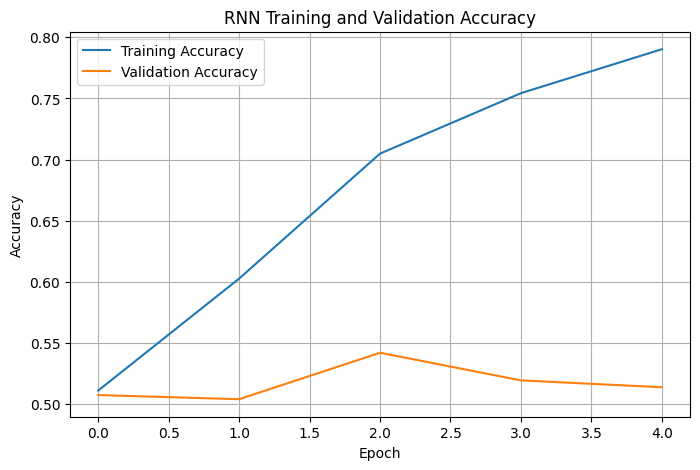

In [ ]:
# Plot RNN Accuracy

plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(rnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("RNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Step 13 — Plot LSTM Training Performance

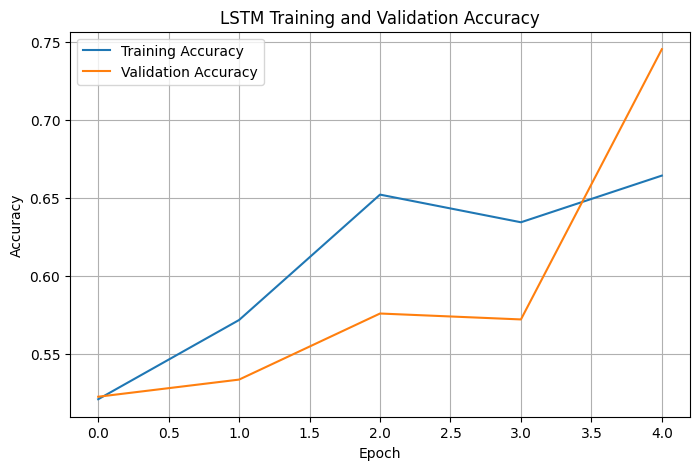

In [ ]:
# Plot LSTM Accuracy

plt.figure(figsize=(8, 5))

plt.plot(lstm_history.history["accuracy"], label="Training Accuracy")
plt.plot(lstm_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Step 14 — Compare RNN and LSTM Accuracy Graphically

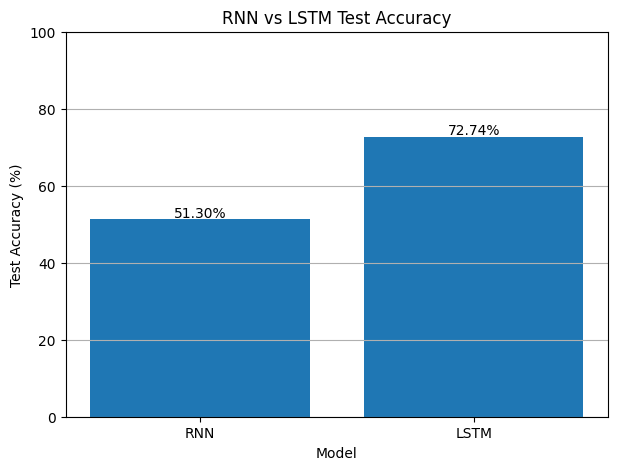

In [ ]:
# Compare RNN and LSTM Test Accuracy

models = ["RNN", "LSTM"]
accuracies = [
    rnn_test_accuracy * 100,
    lstm_test_accuracy * 100
]

plt.figure(figsize=(7, 5))

plt.bar(models, accuracies)

plt.title("RNN vs LSTM Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.ylim(0, 100)
plt.grid(axis="y")

plt.show()

Step 15 — Plot Training and Validation Loss

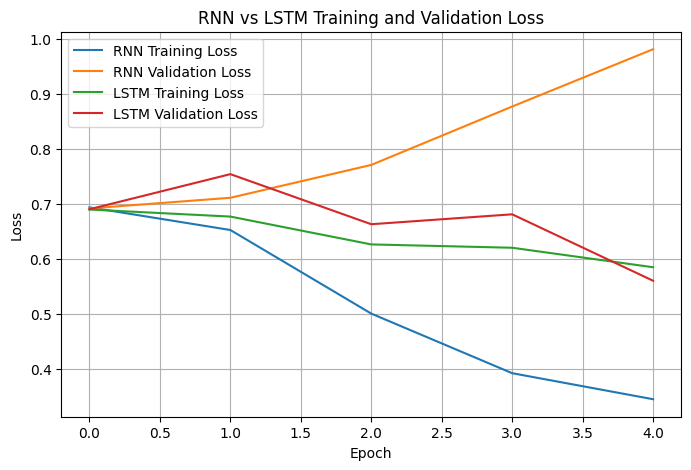

In [ ]:
# Plot RNN and LSTM Loss

plt.figure(figsize=(8, 5))

plt.plot(
    rnn_history.history["loss"],
    label="RNN Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    label="RNN Validation Loss"
)

plt.plot(
    lstm_history.history["loss"],
    label="LSTM Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="LSTM Validation Loss"
)

plt.title("RNN vs LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

Step 16 — Make Predictions on Sample Reviews

In [ ]:
# Function to convert a review into IMDB word-index sequence

word_index = imdb.get_word_index()

def encode_review(review):
    words = review.lower().split()

    encoded = [1]  # Start token

    for word in words:
        index = word_index.get(word, 2)

        # IMDB vocabulary uses indices starting after special tokens
        index = index + 3

        if index < 10000:
            encoded.append(index)
        else:
            encoded.append(2)  # Unknown word

    return pad_sequences(
        [encoded],
        maxlen=200,
        padding="post",
        truncating="post"
    )


# Sample reviews
reviews = [
    "This movie was excellent and I really enjoyed it",
    "The movie was boring and I did not like it",
    "Amazing story with wonderful acting",
    "The film was terrible and disappointing"
]

# Make predictions
for review in reviews:
    encoded_review = encode_review(review)

    rnn_prediction = rnn_model.predict(encoded_review, verbose=0)[0][0]
    lstm_prediction = lstm_model.predict(encoded_review, verbose=0)[0][0]

    rnn_sentiment = "Positive" if rnn_prediction >= 0.5 else "Negative"
    lstm_sentiment = "Positive" if lstm_prediction >= 0.5 else "Negative"

    print("Review:", review)
    print("RNN Prediction :", rnn_sentiment, f"({rnn_prediction:.4f})")
    print("LSTM Prediction:", lstm_sentiment, f"({lstm_prediction:.4f})")
    print("-" * 60)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Review: This movie was excellent and I really enjoyed it
RNN Prediction : Negative (0.4792)
LSTM Prediction: Positive (0.7567)
------------------------------------------------------------
Review: The movie was boring and I did not like it
RNN Prediction : Negative (0.4770)
LSTM Prediction: Negative (0.2608)
------------------------------------------------------------
Review: Amazing story with wonderful acting
RNN Prediction : Positive (0.5577)
LSTM Prediction: Positive (0.7567)
------------------------------------------------------------
Review: The film was terrible and disappointing
RNN Prediction : Positive (0.5467)
LSTM Prediction: Negative (0.2608)
------------------------------------------------------------


Step 17 — Create a Prediction Visualization

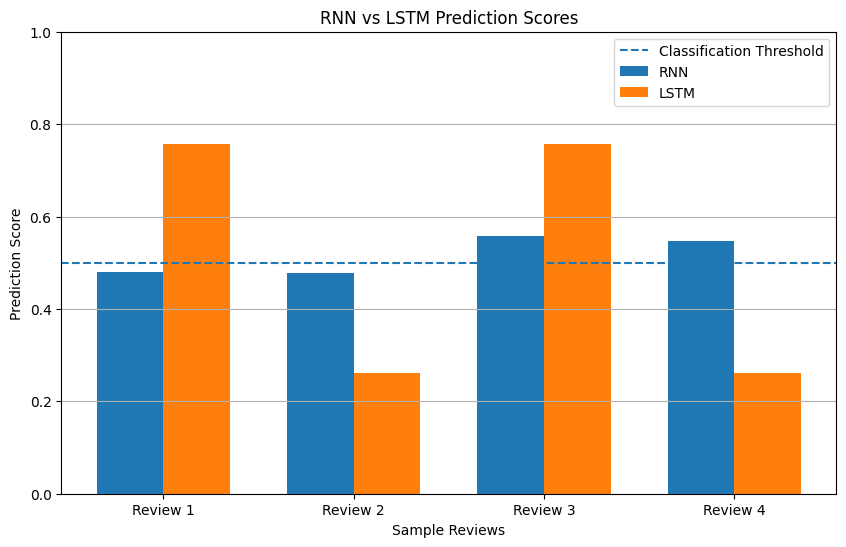

In [ ]:
# Store prediction results

rnn_scores = []
lstm_scores = []

for review in reviews:
    encoded_review = encode_review(review)

    rnn_score = rnn_model.predict(encoded_review, verbose=0)[0][0]
    lstm_score = lstm_model.predict(encoded_review, verbose=0)[0][0]

    rnn_scores.append(rnn_score)
    lstm_scores.append(lstm_score)


# Create visualization

x = np.arange(len(reviews))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    rnn_scores,
    width,
    label="RNN"
)

plt.bar(
    x + width / 2,
    lstm_scores,
    width,
    label="LSTM"
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Classification Threshold"
)

plt.title("RNN vs LSTM Prediction Scores")
plt.xlabel("Sample Reviews")
plt.ylabel("Prediction Score")
plt.xticks(
    x,
    ["Review 1", "Review 2", "Review 3", "Review 4"]
)

plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y")

plt.show()

Step 18 — Create Final Performance Comparison Table

In [ ]:
# Create performance comparison table

comparison = {
    "Model": ["RNN", "LSTM"],
    "Test Accuracy (%)": [
        rnn_test_accuracy * 100,
        lstm_test_accuracy * 100
    ],
    "Test Loss": [
        rnn_test_loss,
        lstm_test_loss
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df["Test Accuracy (%)"] = comparison_df["Test Accuracy (%)"].round(2)
comparison_df["Test Loss"] = comparison_df["Test Loss"].round(4)

print(comparison_df.to_string(index=False))

Model  Test Accuracy (%)  Test Loss
  RNN              51.30     0.9766
 LSTM              72.74     0.5846


Step 19 — Observe Long-Term Dependency Learning

In [ ]:
# Analyze long-term dependency learning

print("Long-Term Dependency Analysis")
print("-" * 40)

print("RNN uses a simple recurrent structure to process sequential information.")
print("It can face difficulty in retaining information from earlier parts of long sequences.")

print("\nLSTM uses memory cells and gates to control information flow.")
print("This helps LSTM retain important information for longer sequences.")

print("\nTherefore, LSTM is designed to handle long-term dependencies more effectively")
print("than a basic RNN.")

Long-Term Dependency Analysis
----------------------------------------
RNN uses a simple recurrent structure to process sequential information.
It can face difficulty in retaining information from earlier parts of long sequences.

LSTM uses memory cells and gates to control information flow.
This helps LSTM retain important information for longer sequences.

Therefore, LSTM is designed to handle long-term dependencies more effectively
than a basic RNN.


Step 20 — Save the Trained Models

In [ ]:
# Save trained RNN and LSTM models

rnn_model.save("rnn_imdb_model.keras")
lstm_model.save("lstm_imdb_model.keras")

print("RNN model saved successfully.")
print("LSTM model saved successfully.")

RNN model saved successfully.
LSTM model saved successfully.


Step 21 — Final Results Summary

In [ ]:
# Final Results Summary

print("=" * 50)
print("FINAL RESULTS - RNN vs LSTM")
print("=" * 50)

print(f"RNN Test Accuracy  : {rnn_test_accuracy * 100:.2f}%")
print(f"RNN Test Loss      : {rnn_test_loss:.4f}")

print("-" * 50)

print(f"LSTM Test Accuracy : {lstm_test_accuracy * 100:.2f}%")
print(f"LSTM Test Loss     : {lstm_test_loss:.4f}")

print("=" * 50)

FINAL RESULTS - RNN vs LSTM
RNN Test Accuracy  : 51.30%
RNN Test Loss      : 0.9766
--------------------------------------------------
LSTM Test Accuracy : 72.74%
LSTM Test Loss     : 0.5846


Step 22 — Add Observations

## Observations

1. The IMDB Movie Reviews Dataset was used for sequence classification.

2. The movie reviews were converted into numerical sequences and padded to a fixed length of 200 tokens.

3. A Simple RNN model was implemented to classify movie reviews as positive or negative.

4. An LSTM model was also implemented using the same dataset and preprocessing steps.

5. Both models were evaluated using test accuracy and test loss.

6. The training and validation accuracy and loss were visualized using graphs.

7. The prediction visualization showed the output scores produced by the RNN and LSTM models for sample reviews.

8. RNN can face difficulty in retaining information from earlier parts of long sequences because of the vanishing gradient problem.

9. LSTM uses memory cells and gates to control information flow, which helps it learn long-term dependencies.

10. The performance comparison between RNN and LSTM was based on the actual test accuracy and test loss obtained during model evaluation.

## RNN vs LSTM Comparison

| Parameter              | RNN                                                 | LSTM                                            |
| ---------------------- | --------------------------------------------------- | ----------------------------------------------- |
| Full Form              | Recurrent Neural Network                            | Long Short-Term Memory                          |
| Architecture           | Simple recurrent structure                          | Recurrent structure with memory cells and gates |
| Memory                 | Limited ability to retain long-term information     | Better ability to retain long-term information  |
| Long-Term Dependencies | Can have difficulty learning long-term dependencies | Designed to handle long-term dependencies       |
| Training               | Generally simpler and faster                        | More complex and computationally expensive      |
| Parameters             | Fewer parameters                                    | More parameters due to gates and memory cells   |
| Use in this task       | Used for IMDB sentiment classification              | Used for IMDB sentiment classification          |
| Performance            | Evaluated using test accuracy and test loss         | Evaluated using test accuracy and test loss     |

### Performance Comparison

The performance of both models was compared using their actual test accuracy and test loss obtained after training. The model with higher test accuracy and lower test loss can be considered better for the given experiment.

The RNN and LSTM models were also compared using training graphs, validation graphs, and sample review predictions. This comparison helped demonstrate the difference between a basic recurrent architecture and an architecture specifically designed to learn long-term dependencies.


## Conclusion

In this task, RNN and LSTM models were implemented for sequence modeling using the IMDB Movie Reviews Dataset. The movie reviews were converted into numerical sequences, padded to a fixed length, and used for binary sentiment classification.

Both RNN and LSTM models were trained and evaluated using test accuracy and test loss. The results and visualizations helped in understanding the performance of both models. The experiment demonstrated that RNN can process sequential data, while LSTM is designed to handle long-term dependencies more effectively through its memory cells and gates.

Overall, this task provided practical understanding of sequence preprocessing, RNN and LSTM implementation, sentiment classification, model evaluation, and performance comparison.
